## 1. Load data

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import torch
if torch.cuda.is_available():
    torch.cuda.set_per_process_memory_fraction(0.95, device=0)

import pandas as pd
import numpy as np
import scanpy as sc
import SpatialMuSC

import matplotlib
# In notebook, inline display is usually more stable than TkAgg.
# If you run this as a script and need a GUI backend, you may uncomment the next line.
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt

os.environ['RPY2_CFFI_MODE'] = 'ABI'
os.environ['R_HOME'] = r'home:\R\R-4.5.0'
os.environ['PATH'] = r'home:\R\R-4.5.0\bin;' + os.environ['PATH']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

file_fold = 'home:/code_data/SpatialGlue_data/Data_SpatialGlue/Data_SpatialGlue/Dataset1_Mouse_Spleen1/'
save_dir = r"home:/Dataset1_Mouse_Spleen1/SpatialMuSC"

data_type = 'SPOTS'
random_seed = 2022
n_clusters = 5
cluster_method = 'mclust'


Using device: cuda


In [2]:
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(file_fold + 'adata_Pro.h5ad')

print('Initial RNA shape:', adata_omics1.shape)
print('Initial Protein shape:', adata_omics2.shape)

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

adata_omics1

Initial RNA shape: (2568, 32285)
Initial Protein shape: (2568, 21)


AnnData object with n_obs × n_vars = 2568 × 32285
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

## 2. RNA preprocessing

In [3]:
from SpatialMuSC.preprocess import fix_seed, clr_normalize_each_cell, pca, construct_neighbor_graph

fix_seed(random_seed)
print('Random seed fixed:', random_seed)

Random seed fixed: 2022


In [4]:
sc.pp.filter_genes(adata_omics1, min_cells=10)
print('RNA shape after filter_genes:', adata_omics1.shape)

sc.pp.highly_variable_genes(adata_omics1, flavor='seurat_v3', n_top_genes=3000)
print('Number of highly variable genes:', int(adata_omics1.var['highly_variable'].sum()))

sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
sc.pp.scale(adata_omics1)

adata_omics1_high = adata_omics1[:, adata_omics1.var['highly_variable']]
print('RNA HVG matrix shape:', adata_omics1_high.shape)

adata_omics1.obsm['feat'] = pca(adata_omics1_high, n_comps=adata_omics2.n_vars - 1)
print('RNA feature shape:', adata_omics1.obsm['feat'].shape)

RNA shape after filter_genes: (2568, 14343)
Number of highly variable genes: 3000
RNA HVG matrix shape: (2568, 3000)
RNA feature shape: (2568, 20)


## 3. Protein preprocessing

In [5]:
adata_omics2 = clr_normalize_each_cell(adata_omics2)
sc.pp.scale(adata_omics2)

adata_omics2.obsm['feat'] = pca(adata_omics2, n_comps=adata_omics2.n_vars - 1)

print('Final RNA shape:', adata_omics1.shape)
print('Final Protein shape:', adata_omics2.shape)
print('Protein feature shape:', adata_omics2.obsm['feat'].shape)

adata_omics2

Final RNA shape: (2568, 14343)
Final Protein shape: (2568, 21)
Protein feature shape: (2568, 20)


AnnData object with n_obs × n_vars = 2568 × 21
    var: 'mean', 'std'
    obsm: 'spatial', 'feat'

## 4. Model training

In [6]:
data = construct_neighbor_graph(adata_omics1, adata_omics2, datatype=data_type)
print('Neighbor graph constructed.')
type(data)

same true： True
Neighbor graph constructed.


dict

In [7]:
from SpatialMuSC.SpatialMuSC_pyG import Train_SpatialMuSC

model = Train_SpatialMuSC(data, datatype=data_type, device=device)
output = model.train()

print(output.keys())

100%|██████████| 1000/1000 [02:43<00:00,  6.10it/s]


dict_keys(['emb_latent_omics1', 'emb_latent_omics2', 'SpatialMuSC'])


In [10]:
adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1'].copy()
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2'].copy()
adata.obsm['SpatialMuSC'] = output['SpatialMuSC'].copy()

print('emb_latent_omics1 shape:', adata.obsm['emb_latent_omics1'].shape)
print('emb_latent_omics2 shape:', adata.obsm['emb_latent_omics2'].shape)
print('SpatialMuSC embedding shape:', adata.obsm['SpatialMuSC'].shape)

emb_latent_omics1 shape: (2568, 64)
emb_latent_omics2 shape: (2568, 64)
SpatialMuSC embedding shape: (2568, 64)


## 5. Clustering

In [11]:
from SpatialMuSC.utils import clustering

clustering(
    adata,
    key='SpatialMuSC',
    add_key='SpatialMuSC',
    n_clusters=n_clusters,
    method=cluster_method,
    use_pca=True
)

adata.obs['SpatialMuSC'].head()

R callback write-console:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.
  


fitting ...
  |======================================================================| 100%


AAACACCAATAACTGC-1    5
AAACAGAGCGACTCCT-1    1
AAACAGCTTTCAGAAG-1    5
AAACAGGGTCTATATT-1    3
AAACCGGGTAGGTACC-1    1
Name: SpatialMuSC, dtype: category
Categories (5, int32): [1, 2, 3, 4, 5]

In [12]:
print('Unique predicted labels:', sorted(adata.obs['SpatialMuSC'].unique()))
print('Number of clusters:', adata.obs['SpatialMuSC'].nunique())

adata.obs['SpatialMuSC'].value_counts().sort_index()

Unique predicted labels: [1, 2, 3, 4, 5]
Number of clusters: 5


SpatialMuSC
1    729
2    325
3    445
4    467
5    602
Name: count, dtype: int64

## 6. Evaluation

In [13]:
# Evaluation is intentionally omitted in this notebook.
print('Evaluation is omitted.')

Evaluation is omitted.


## 7. Visualization

In [14]:
# Flip tissue image, following the original script logic.
adata.obsm['spatial'] = np.rot90(np.rot90(np.rot90(np.array(adata.obsm['spatial'])).T).T).T
adata.obsm['spatial'][:, 1] = -1 * adata.obsm['spatial'][:, 1]

sc.pp.neighbors(adata, use_rep='SpatialMuSC', n_neighbors=10)
sc.tl.umap(adata)

print('UMAP finished.')

UMAP finished.


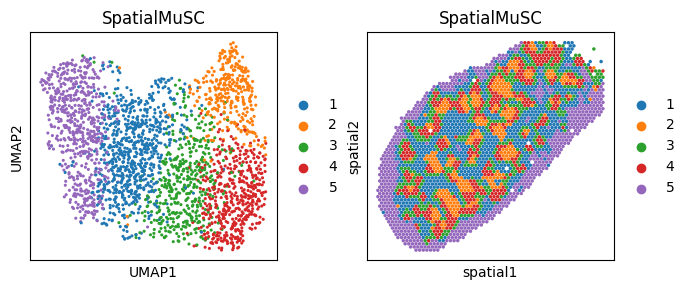

In [15]:
# UMAP + Spatial
%matplotlib inline

fig, ax_list = plt.subplots(1, 2, figsize=(7, 3))

sc.pl.umap(
    adata,
    color='SpatialMuSC',
    ax=ax_list[0],
    title='SpatialMuSC',
    s=20,
    show=False
)

sc.pl.embedding(
    adata,
    basis='spatial',
    color='SpatialMuSC',
    ax=ax_list[1],
    title='SpatialMuSC',
    s=25,
    show=False
)

plt.tight_layout(w_pad=0.3)
plt.show()

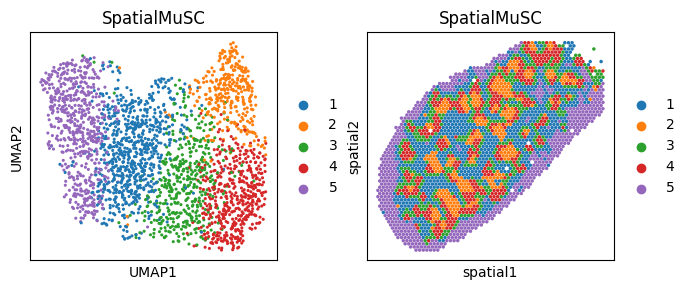

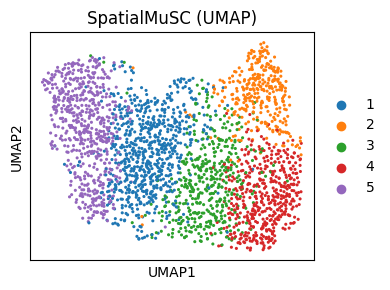

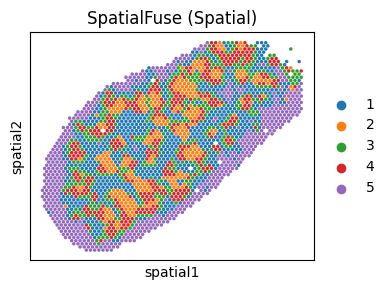

In [17]:
# Save UMAP + Spatial, UMAP only, and Spatial only.
os.makedirs(save_dir, exist_ok=True)

# Save the combined 1x2 figure.
fig, ax_list = plt.subplots(1, 2, figsize=(7, 3))

sc.pl.umap(
    adata,
    color='SpatialMuSC',
    ax=ax_list[0],
    title='SpatialMuSC',
    s=20,
    show=False
)

sc.pl.embedding(
    adata,
    basis='spatial',
    color='SpatialMuSC',
    ax=ax_list[1],
    title='SpatialMuSC',
    s=25,
    show=False
)

plt.tight_layout(w_pad=0.3)

out_base = os.path.join(save_dir, "block1_umap+spatial")
plt.show()

# Save UMAP only.
fig_u1, ax_u1 = plt.subplots(figsize=(4, 3))
sc.pl.umap(adata, color='SpatialMuSC', ax=ax_u1, title='SpatialMuSC (UMAP)', s=20, show=False)
plt.tight_layout()
plt.show()

# Save spatial only.
fig_s1, ax_s1 = plt.subplots(figsize=(4, 3))
sc.pl.embedding(adata, basis='spatial', color='SpatialMuSC', ax=ax_s1, title='SpatialFuse (Spatial)', s=25, show=False)
plt.tight_layout()
plt.show()
